# FEATURE BASED ADAPTATION

In [2]:
from datasets import load_dataset

dataset = load_dataset("universal-dependencies/universal_dependencies")
train, dev, test = dataset["train"], dataset["dev"], dataset["test"]

print(train)
print(train[0]["tokens"])
print(train[0]["upos"])

README.md:   0%|          | 0.00/90.7k [00:00<?, ?B/s]

parquet/en_ewt/dev.parquet: reconstructing file:   0%|          |  0.00B /  516kB            

parquet/en_ewt/dev.parquet: downloading bytes:           |  0.00B            

parquet/en_ewt/test.parquet: reconstructing file:   0%|          |  0.00B /  523kB            

parquet/en_ewt/test.parquet: downloading bytes:           |  0.00B            

...

parquet/en_ewt/train.parquet: downloading bytes:           |  0.00B            

Generating dev split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['sent_id', 'text', 'comments', 'tokens', 'lemmas', 'upos', 'xpos', 'feats', 'head', 'deprel', 'deps', 'misc', 'mwt', 'empty_nodes'],
    num_rows: 12544
})
['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'PROPN', 'PUNCT', 'ADP', 'DET', 'ADJ', 'NOUN', 'PUNCT']


In [3]:
import torch
from transformers import AutoTokenizer, AutoModel

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModel.from_pretrained(model_ckpt).to(device).eval()
print(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cuda


In [4]:
import numpy as np
from tqdm.auto import tqdm

def extract_word_features(ds, batch_size=32):
    """
    Devuelve un vector de 768 por PALABRA (no por oración) y su etiqueta UPOS.
    Si una palabra se parte en varios subwords, usa el primero.
    """
    feats, labels = [], []
    for i in tqdm(range(0, len(ds), batch_size)):
        batch = ds[i:i + batch_size]
        words, tags = batch["tokens"], batch["upos"]

        enc = tokenizer(words, is_split_into_words=True, truncation=True,
                        max_length=512, padding=True, return_tensors="pt")
        with torch.no_grad():
            out = model(input_ids=enc["input_ids"].to(device),
                        attention_mask=enc["attention_mask"].to(device)
                        ).last_hidden_state.cpu().numpy()

        for b in range(len(words)):
            seen = set()
            for pos, wid in enumerate(enc.word_ids(batch_index=b)):
                if wid is None or wid in seen:   # [CLS], [SEP], padding, subwords extra
                    continue
                seen.add(wid)
                if tags[b][wid] == "_":          # por si hay tokens sin etiqueta
                    continue
                feats.append(out[b, pos])
                labels.append(tags[b][wid])

    return np.vstack(feats), np.array(labels)

X_train, y_train = extract_word_features(train)
X_val,   y_val   = extract_word_features(dev)
X_test,  y_test  = extract_word_features(test)

print("train:", X_train.shape, y_train.shape)
print("val:  ", X_val.shape,   y_val.shape)
print("test: ", X_test.shape,  y_test.shape)

  0%|          | 0/392 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/65 [00:00<?, ?it/s]

train: (204578, 768) (204578,)
val:   (25148, 768) (25148,)
test:  (25094, 768) (25094,)


In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, C=1.0, random_state=42)
)

print("Entrenando...")
clf.fit(X_train, y_train)
print("¡Listo!")

Entrenando...
¡Listo!


In [6]:
from sklearn.metrics import accuracy_score, classification_report

for name, X, y in [("Validación", X_val, y_val), ("Test", X_test, y_test)]:
    y_pred = clf.predict(X)
    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y, y_pred) * 100:.2f}%\n")
    print(classification_report(y, y_pred, digits=3))


===== Validación =====
Accuracy: 95.14%

              precision    recall  f1-score   support

         ADJ      0.908     0.903     0.906      1865
         ADP      0.963     0.969     0.966      2038
         ADV      0.909     0.904     0.907      1232
         AUX      0.978     0.983     0.980      1567
       CCONJ      0.991     0.992     0.992       780
         DET      0.983     0.986     0.985      1900
        INTJ      0.917     0.765     0.834       115
        NOUN      0.923     0.938     0.930      4210
         NUM      0.964     0.971     0.967       383
        PART      0.994     0.988     0.991       647
        PRON      0.982     0.991     0.986      2225
       PROPN      0.896     0.871     0.883      1867
       PUNCT      0.994     0.995     0.994      3075
       SCONJ      0.919     0.917     0.918       397
         SYM      0.750     0.815     0.781        81
        VERB      0.962     0.951     0.956      2707
           X      0.491     0.441     0

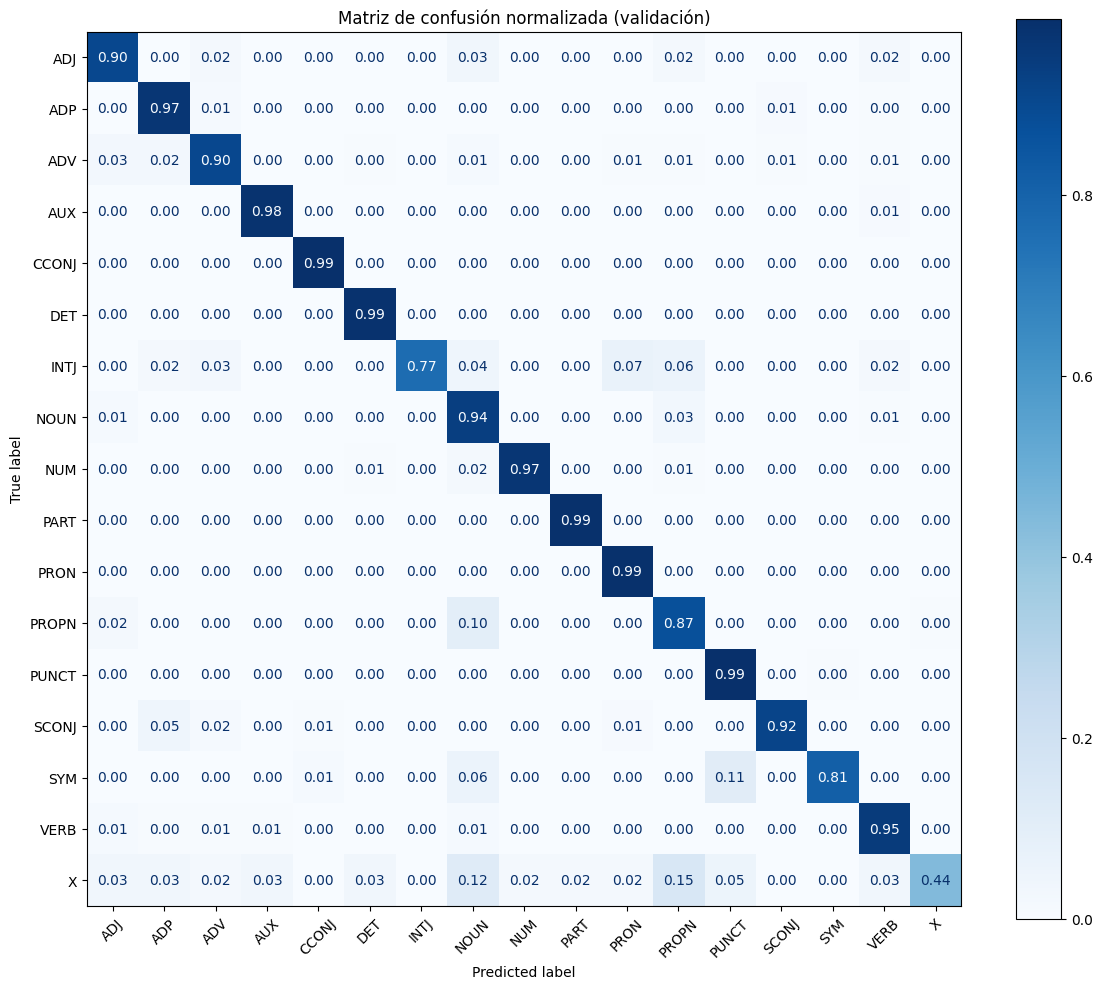

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_val, clf.predict(X_val), normalize="true",
    xticks_rotation=45, values_format=".2f", cmap="Blues", ax=ax
)
plt.title("Matriz de confusión normalizada (validación)")
plt.tight_layout()
plt.show()

In [8]:
import joblib

joblib.dump(clf, "modelo_pos_logistic_regression.joblib")
print("Modelo guardado.")
clf = joblib.load("modelo_pos_logistic_regression.joblib")

Modelo guardado.


PARTIAL FINE-TUNING 2 LAYERS

In [9]:
from transformers import AutoTokenizer

model_ckpt = "distilbert-base-uncased"
N_UNFROZEN = 2
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Mapeo de etiquetas UPOS
label_list = sorted({t for tags in train["upos"] for t in tags if t != "_"})
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}
print(len(label_list), label_list)

def tokenize_and_align(batch):
    enc = tokenizer(batch["tokens"], is_split_into_words=True,
                    truncation=True, max_length=512)
    all_labels = []
    for b, tags in enumerate(batch["upos"]):
        labels, prev = [], None
        for wid in enc.word_ids(batch_index=b):
            if wid is None or wid == prev:          # especiales o subwords extra
                labels.append(-100)
            else:
                labels.append(label2id.get(tags[wid], -100))
            prev = wid
        all_labels.append(labels)
    enc["labels"] = all_labels
    return enc

cols = train.column_names
train_tok = train.map(tokenize_and_align, batched=True, remove_columns=cols)
dev_tok   = dev.map(tokenize_and_align,   batched=True, remove_columns=cols)
test_tok  = test.map(tokenize_and_align,  batched=True, remove_columns=cols)

17 ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


Map:   0%|          | 0/12544 [00:00<?, ? examples/s]

Map:   0%|          | 0/2001 [00:00<?, ? examples/s]

Map:   0%|          | 0/2077 [00:00<?, ? examples/s]

In [10]:
import torch
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    model_ckpt, num_labels=len(label_list),
    id2label=id2label, label2id=label2id
)

# Congelar todo el encoder
for p in model.distilbert.parameters():
    p.requires_grad = False

# Descongelar las últimas 2 capas transformer (de 6)
for layer in model.distilbert.transformer.layer[-N_UNFROZEN:]:
    for p in layer.parameters():
        p.requires_grad = True

# La cabeza de clasificación siempre se entrena
for p in model.classifier.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Entrenables: 14,188,817 / 66,375,953 (21.4%)


In [11]:
import math
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification

EPOCHS, BATCH, LR = 3, 32, 5e-5
total_steps = math.ceil(len(train_tok) / BATCH) * EPOCHS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    mask = labels != -100
    return {"accuracy": (preds[mask] == labels[mask]).mean()}

args = TrainingArguments(
    output_dir="pos-distilbert-2capas",
    learning_rate=LR,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=64,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_steps=int(0.1 * total_steps),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    logging_steps=100,
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=train_tok, eval_dataset=dev_tok,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.175069,0.153200,0.955901
2,0.107244,0.127455,0.962860
3,0.088157,0.122951,0.964729


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1176, training_loss=0.2968124706728929, metrics={'train_runtime': 26.6259, 'train_samples_per_second': 1413.359, 'train_steps_per_second': 44.167, 'total_flos': 585639831908928.0, 'train_loss': 0.2968124706728929, 'epoch': 3.0})

In [12]:
import numpy as np
from sklearn.metrics import classification_report

def evaluar(ds_tok, nombre):
    out = trainer.predict(ds_tok)
    preds = out.predictions.argmax(-1)
    mask = out.label_ids != -100
    y_true = np.array([id2label[i] for i in out.label_ids[mask]])
    y_pred = np.array([id2label[i] for i in preds[mask]])
    acc = (y_true == y_pred).mean()
    print(f"\n===== {nombre} =====")
    print(f"Accuracy: {acc*100:.2f}%  ({mask.sum():,} palabras)\n")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))
    return y_true, y_pred

y_val_true,  y_val_pred  = evaluar(dev_tok,  "Validación")
y_test_true, y_test_pred = evaluar(test_tok, "Test")


===== Validación =====
Accuracy: 96.47%  (25,148 palabras)

              precision    recall  f1-score   support

         ADJ      0.943     0.932     0.938      1865
         ADP      0.974     0.982     0.978      2038
         ADV      0.931     0.935     0.933      1232
         AUX      0.984     0.993     0.988      1567
       CCONJ      0.999     0.992     0.995       780
         DET      0.991     0.991     0.991      1900
        INTJ      0.879     0.757     0.813       115
        NOUN      0.933     0.957     0.944      4210
         NUM      0.964     0.984     0.974       383
        PART      0.986     0.983     0.985       647
        PRON      0.993     0.995     0.994      2225
       PROPN      0.915     0.891     0.903      1867
       PUNCT      0.996     0.997     0.996      3075
       SCONJ      0.987     0.950     0.968       397
         SYM      0.816     0.877     0.845        81
        VERB      0.977     0.973     0.975      2707
           X      0.


===== Test =====
Accuracy: 96.50%  (25,094 palabras)

              precision    recall  f1-score   support

         ADJ      0.929     0.933     0.931      1788
         ADP      0.969     0.985     0.977      2025
         ADV      0.953     0.942     0.948      1191
         AUX      0.995     0.995     0.995      1543
       CCONJ      0.996     0.989     0.993       736
         DET      0.991     0.993     0.992      1897
        INTJ      0.918     0.835     0.874       121
        NOUN      0.940     0.950     0.945      4123
         NUM      0.951     0.976     0.964       542
        PART      0.989     0.994     0.992       649
        PRON      0.993     0.994     0.994      2164
       PROPN      0.917     0.890     0.903      2075
       PUNCT      0.994     0.993     0.994      3096
       SCONJ      0.976     0.951     0.963       384
         SYM      0.795     0.858     0.826       113
        VERB      0.972     0.980     0.976      2605
           X      0.714   

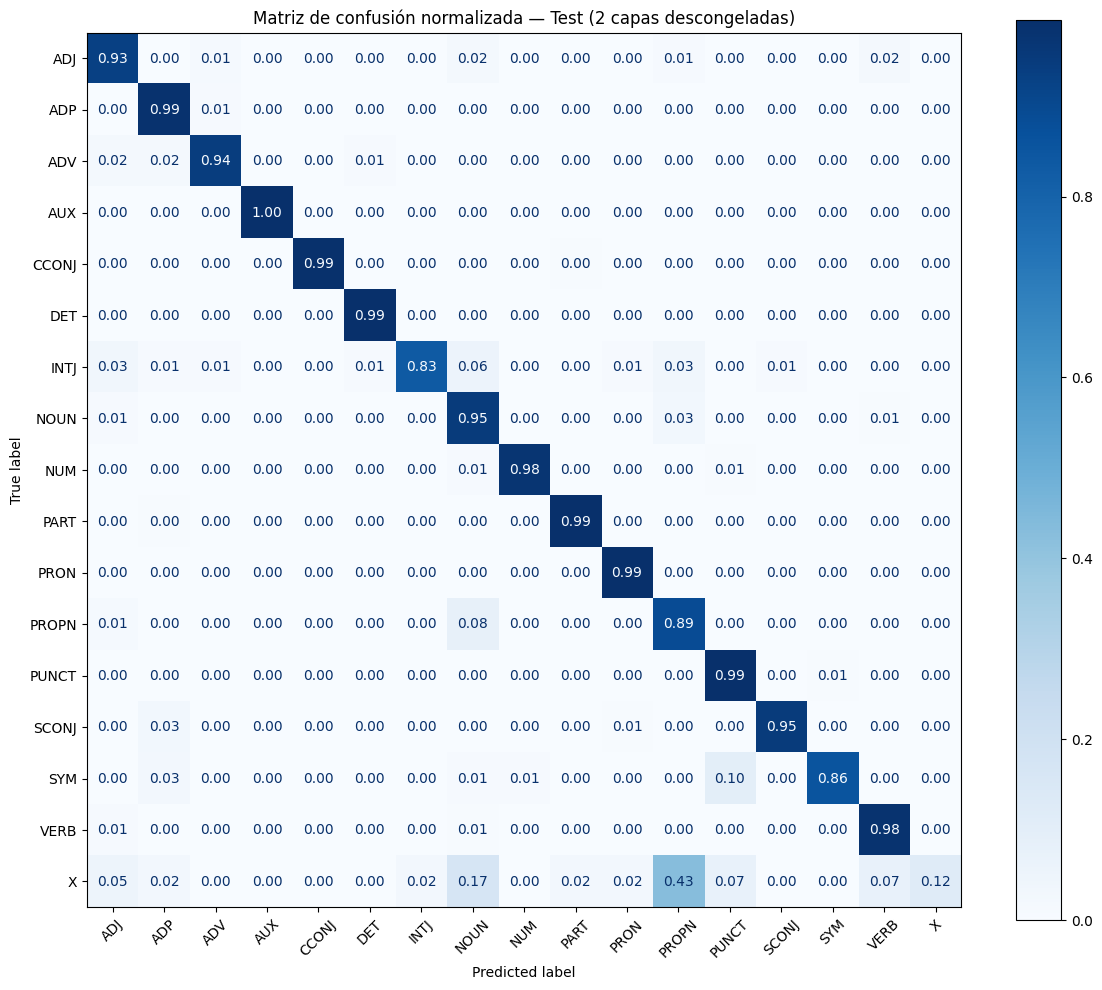

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en pos-distilbert-2capas-final/


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test_true, y_test_pred, labels=label_list, normalize="true",
    xticks_rotation=45, values_format=".2f", cmap="Blues", ax=ax
)
plt.title("Matriz de confusión normalizada — Test (2 capas descongeladas)")
plt.tight_layout()
plt.show()

# Guardar modelo y tokenizer
trainer.save_model("pos-distilbert-2capas-final")
tokenizer.save_pretrained("pos-distilbert-2capas-final")
print("Modelo guardado en pos-distilbert-2capas-final/")

Saving the feature based

In [14]:
!pip install -q skops

import os, json, textwrap
import sklearn, skops, transformers, torch
from skops.io import dump

REPO_ID = "TU_USUARIO/distilbert-pos-ewt-linear-probe"
OUT_DIR = "pos-linear-probe"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- 1. Métricas reales para la model card ----------
dev_acc  = clf.score(X_val,  y_val)
test_acc = clf.score(X_test, y_test)
print(f"Dev: {dev_acc*100:.2f}% | Test: {test_acc*100:.2f}%")

# ---------- 2. Modelo en formato seguro ----------
dump(clf, os.path.join(OUT_DIR, "model.skops"))

# ---------- 3. Receta de features + metadatos ----------
config = {
    "feature_extractor": "distilbert-base-uncased",
    "layer": "last_hidden_state",
    "subword_pooling": "first",
    "tokenization": {"is_split_into_words": True, "truncation": True, "max_length": 512},
    "classifier": "StandardScaler -> LogisticRegression(lbfgs, C=1.0, max_iter=1000)",
    "labels": [str(c) for c in clf.classes_],
    "dataset": "universal-dependencies/universal_dependencies (en_ewt)",
    "metrics": {"dev_accuracy": round(float(dev_acc), 4), "test_accuracy": round(float(test_acc), 4)},
}
with open(os.path.join(OUT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

# ---------- 4. Versiones ----------
with open(os.path.join(OUT_DIR, "requirements.txt"), "w") as f:
    f.write(f"scikit-learn=={sklearn.__version__}\n"
            f"skops=={skops.__version__}\n"
            f"transformers=={transformers.__version__}\n"
            f"torch\nnumpy\nhuggingface_hub\n")

# ---------- 5. Script de inferencia autocontenido ----------
inference_py = textwrap.dedent('''
    """Inferencia del linear probe UPOS sobre DistilBERT congelado.
    Espera oraciones ya tokenizadas en palabras (como en UD)."""
    import os, json
    import numpy as np
    import torch
    from transformers import AutoTokenizer, AutoModel
    from skops.io import load, get_untrusted_types

    DEFAULT_REPO = "__REPO__"

    def load_probe(path_or_repo=DEFAULT_REPO):
        if os.path.isdir(path_or_repo):
            folder = path_or_repo
        else:
            from huggingface_hub import snapshot_download
            folder = snapshot_download(path_or_repo)
        with open(os.path.join(folder, "config.json")) as f:
            cfg = json.load(f)
        model_path = os.path.join(folder, "model.skops")
        untrusted = get_untrusted_types(file=model_path)
        if untrusted:
            print("Tipos no estandar en el modelo (revisalos):", untrusted)
        return load(model_path, trusted=untrusted), cfg

    class POSProbe:
        def __init__(self, path_or_repo=DEFAULT_REPO, device=None):
            self.clf, self.cfg = load_probe(path_or_repo)
            self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
            name = self.cfg["feature_extractor"]
            self.tok = AutoTokenizer.from_pretrained(name)
            self.bert = AutoModel.from_pretrained(name).to(self.device).eval()

        def features(self, words):
            enc = self.tok(words, is_split_into_words=True, truncation=True,
                           max_length=512, return_tensors="pt")
            with torch.no_grad():
                h = self.bert(input_ids=enc["input_ids"].to(self.device),
                              attention_mask=enc["attention_mask"].to(self.device)
                              ).last_hidden_state[0].cpu().numpy()
            vecs, seen = [], set()
            for pos, wid in enumerate(enc.word_ids()):
                if wid is None or wid in seen:
                    continue
                seen.add(wid)
                vecs.append(h[pos])
            return np.vstack(vecs)

        def tag(self, words):
            if isinstance(words, str):
                words = words.split()
            feats = self.features(words)
            return list(zip(words[:len(feats)], self.clf.predict(feats)))

    if __name__ == "__main__":
        probe = POSProbe(os.path.dirname(os.path.abspath(__file__)))
        print(probe.tag(["The", "quick", "brown", "fox", "jumps", "over", "the", "lazy", "dog", "."]))
''').replace("__REPO__", REPO_ID).lstrip()

with open(os.path.join(OUT_DIR, "inference.py"), "w") as f:
    f.write(inference_py)

# ---------- 6. Model card ----------
readme = f"""---
language: en
license: cc-by-sa-4.0
library_name: sklearn
base_model: distilbert-base-uncased
datasets:
- universal-dependencies/universal_dependencies
metrics:
- accuracy
tags:
- sklearn
- skops
- pos-tagging
- upos
- probing
- linear-probe
---

# Linear probe de POS (UPOS) sobre DistilBERT congelado

Regresión logística entrenada sobre representaciones **congeladas** de `distilbert-base-uncased`
para etiquetado UPOS ({len(clf.classes_)} etiquetas) en UD English EWT.

Este repo contiene **solo el clasificador**. DistilBERT no está incluido: se descarga aparte
y se usa sin modificar como extractor de features.

## Receta de features (obligatoria)
- Modelo: `distilbert-base-uncased`, sin fine-tuning
- Capa: `last_hidden_state` (última de 6)
- Un vector de 768 por palabra: el del **primer subword**
- Tokenización: `is_split_into_words=True`, `truncation=True`, `max_length=512`

Si las features se extraen de otra forma, el modelo carga sin error pero sus predicciones no son válidas.

## Clasificador
`StandardScaler` → `LogisticRegression` (lbfgs, C=1.0, max_iter=1000), guardado con `skops`.

## Resultados (accuracy a nivel palabra)
| Split | Accuracy |
|---|---|
| Dev  | {dev_acc*100:.2f}% |
| Test | {test_acc*100:.2f}% |

## Uso
Instala `requirements.txt`, descarga `inference.py` y:

```python
from inference import POSProbe
probe = POSProbe()   # descarga el clasificador de este repo
probe.tag(["I", "love", "Mérida", "."])
```

La entrada debe estar tokenizada en palabras (estilo UD). `str.split()` no separa puntuación.

## Archivos
- `model.skops`: pipeline de sklearn (scaler + regresión logística)
- `config.json`: receta de features, etiquetas y métricas
- `inference.py`: extracción de features + predicción
- `requirements.txt`: versiones usadas en el entrenamiento

## Licencia
Entrenado con UD English EWT (CC BY-SA 4.0). DistilBERT es Apache 2.0.
"""
with open(os.path.join(OUT_DIR, "README.md"), "w") as f:
    f.write(readme)

print(f"\nEntregable listo en ./{OUT_DIR}/")
for fn in sorted(os.listdir(OUT_DIR)):
    print(f"  {fn:18s} {os.path.getsize(os.path.join(OUT_DIR, fn))/1024:8.1f} KB")

Dev: 95.14% | Test: 95.25%

Entregable listo en ./pos-linear-probe/
  README.md               1.8 KB
  config.json             0.7 KB
  inference.py            2.3 KB
  model.skops           143.7 KB
  requirements.txt        0.1 KB
